## Customer Segmentation Classification — Loan Status Prediction

**Nama Anggota:**
- 13523139 — Jonathan Kenan Budianto
- 13523136 — Danendra Shafi Athallah

**Kelas:** K03

---

## 0. Import Libraries & Load Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# Ensemble models
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    StackingClassifier,
    VotingClassifier,
    ExtraTreesClassifier
)

# Naive Bayes
from sklearn.naive_bayes import GaussianNB

# Utils
from sklearn.utils.class_weight import compute_sample_weight

# Evaluation
from sklearn.metrics import classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay

# TODO: Tambahkan import lainnya sesuai kebutuhan

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42

In [ ]:
# Load dataset
# Jika menggunakan Google Colab:
# from google.colab import drive
# drive.mount('/content/drive')

train_df = pd.read_csv('train.csv')   # TODO: sesuaikan path
test_df  = pd.read_csv('test.csv')    # TODO: sesuaikan path

print("Train shape:", train_df.shape)
print("Test shape: ", test_df.shape)

Train shape: (36000, 13)
Test shape:  (9000, 12)


---
## 1. Exploratory Data Analysis (EDA)

> **Tujuan:** Memahami data secara mendalam sebelum preprocessing dan modeling.
> **Requirement:** Minimal **3 visualisasi** dengan **3 pertanyaan** (1 per visualisasi).

### 1.1 Gambaran Umum Dataset

In [ ]:
train_df.head()

,person_id,person_age,person_gender,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,6049,24.0,male,58914.0,2,OWN,4400.0,5.99,0.07,4.0,656,Yes,0
1,3347,23.0,female,45873.0,2,RENT,11000.0,11.01,0.24,2.0,634,Yes,0
2,17999,29.0,female,240947.0,7,MORTGAGE,10000.0,12.69,0.04,9.0,638,Yes,0
3,24989,30.0,female,96316.0,10,MORTGAGE,6000.0,13.49,0.06,8.0,682,No,0
4,23232,29.0,male,73033.0,7,MORTGAGE,8000.0,10.51,0.11,8.0,644,Yes,0


In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36000 entries, 0 to 35999
Data columns (total 13 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_id                       36000 non-null  int64  
 1   person_age                      36000 non-null  float64
 2   person_gender                   36000 non-null  object 
 3   person_income                   36000 non-null  float64
 4   person_emp_exp                  36000 non-null  int64  
 5   person_home_ownership           36000 non-null  object 
 6   loan_amnt                       36000 non-null  float64
 7   loan_int_rate                   36000 non-null  float64
 8   loan_percent_income             36000 non-null  float64
 9   cb_person_cred_hist_length      36000 non-null  float64
 10  credit_score                    36000 non-null  int64  
 11  previous_loan_defaults_on_file  36000 non-null  object 
 12  loan_status                     

In [ ]:
train_df.describe(include='all')

,person_id,person_age,person_gender,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
count,36000.000000,36000.000000,36000,3.600000e+04,36000.000000,36000,36000.000000,36000.000000,36000.000000,36000.000000,36000.000000,36000,36000.000000
unique,NaN,NaN,2,NaN,NaN,4,NaN,NaN,NaN,NaN,NaN,2,NaN
top,NaN,NaN,male,NaN,NaN,RENT,NaN,NaN,NaN,NaN,NaN,Yes,NaN
freq,NaN,NaN,19786,NaN,NaN,18730,NaN,NaN,NaN,NaN,NaN,18263,NaN
mean,22495.468833,27.763194,NaN,8.054947e+04,5.405611,NaN,9586.962861,11.013158,0.139635,5.863444,632.649583,NaN,0.222222
std,12995.590721,6.045354,NaN,8.431697e+04,6.064240,NaN,6301.447426,2.976288,0.086949,3.878709,50.292346,NaN,0.415745
min,2.000000,20.000000,NaN,8.000000e+03,0.000000,NaN,500.000000,5.420000,0.000000,2.000000,390.000000,NaN,0.000000
25%,11236.750000,24.000000,NaN,4.716350e+04,1.000000,NaN,5000.000000,8.590000,0.070000,3.000000,602.000000,NaN,0.000000
50%,22467.500000,26.000000,NaN,6.708100e+04,4.000000,NaN,8000.000000,11.010000,0.120000,4.000000,640.000000,NaN,0.000000
75%,33754.500000,30.000000,NaN,9.626075e+04,8.000000,NaN,12235.000000,13.022500,0.190000,8.000000,670.000000,NaN,0.000000


In [ ]:
# Cek missing values
missing = train_df.isnull().sum()
missing_pct = (missing / len(train_df) * 100).round(2)
pd.DataFrame({'Missing Count': missing, 'Missing (%)': missing_pct}).query('`Missing Count` > 0')

,Missing Count,Missing (%)


In [ ]:
# Distribusi kelas target
print(train_df['loan_status'].value_counts())
print(train_df['loan_status'].value_counts(normalize=True).round(3))

loan_status
0    28000
1     8000
Name: count, dtype: int64
loan_status
0    0.778
1    0.222
Name: proportion, dtype: float64


### 1.2 Visualisasi 1 — Distribusi Kelas Target

**Pertanyaan:** *Bagaimana distribusi kelas target (Approved vs Rejected) pada dataset? Apakah terdapat class imbalance?*

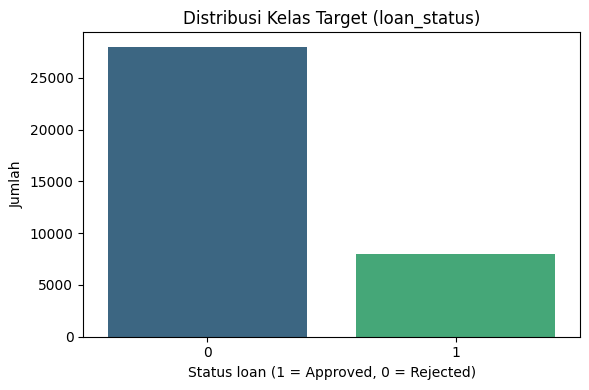

In [ ]:
# Snippet: countplot untuk fitur kategorik vs target
# -------------------------------------------------------
# fig, axes = plt.subplots(1, 2, figsize=(12, 4))
#
# sns.countplot(data=train_df, x='NAMA_KOLOM', ax=axes[0])
# axes[0].set_title('Distribusi NAMA_KOLOM')
#
# sns.countplot(data=train_df, x='NAMA_KOLOM', hue='loan_status', ax=axes[1])
# axes[1].set_title('NAMA_KOLOM vs Loan Status')
#
# plt.tight_layout()
# plt.show()
# -------------------------------------------------------

# TODO: Buat visualisasi pertama Anda

TARGET_COL = 'loan_status'

plt.figure(figsize=(6, 4))
sns.countplot(data=train_df, x=TARGET_COL, palette='viridis')
plt.title(f'Distribusi Kelas Target ({TARGET_COL})')
plt.xlabel('Status loan (1 = Approved, 0 = Rejected)')
plt.ylabel('Jumlah')
plt.tight_layout()
plt.show()

**Analisis:**  
Berdasarkan visualisasi distribusi kelas target, dataset menunjukkan adanya **class imbalance** yang signifikan. Kelas Rejected (0) memiliki 28.000 sampel (77.8%), sedangkan kelas Approved (1) hanya memiliki 8.000 sampel (22.2%). Perbandingan kelas adalah sekitar 3.5:1, yang termasuk dalam kategori *moderate imbalance*.

Ketidakseimbangan ini dapat memengaruhi performa model karena cenderung bias terhadap kelas mayoritas (Rejected). Oleh karena itu, perlu dilakukan penanganan seperti penggunaan `class_weight='balanced'` pada model atau metode lain untuk memastikan model dapat mempelajari kedua kelas dengan baik.

### 1.3 Visualisasi 2 — Heatmap Korelasi Fitur

**Pertanyaan:** *Fitur mana yang memiliki korelasi tinggi dengan target loan_status? Apakah ada multikolinearitas antar fitur?*

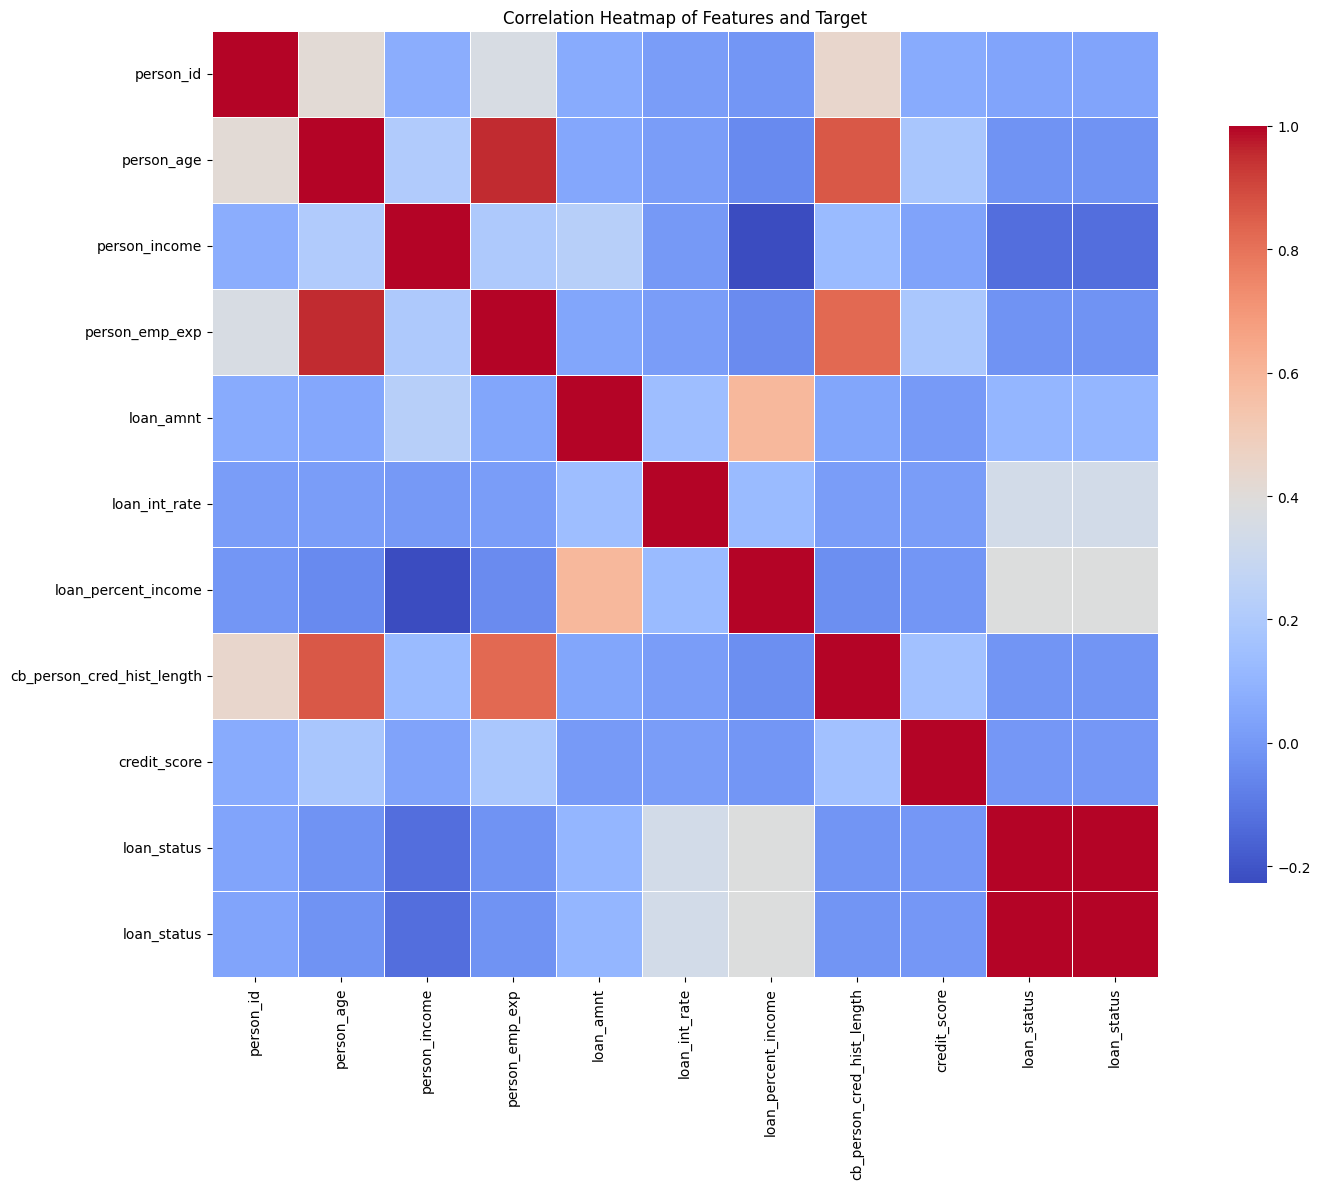

In [ ]:
# Snippet: heatmap korelasi fitur numerik
# -------------------------------------------------------
# num_cols = train_df.select_dtypes(include=np.number).columns.tolist()
#
# plt.figure(figsize=(12, 8))
# corr_matrix = train_df[num_cols].corr()
# sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
#             square=True, linewidths=0.5)
# plt.title('Correlation Heatmap')
# plt.tight_layout()
# plt.show()
# -------------------------------------------------------

# TODO: Buat visualisasi kedua Anda

# Buat salinan untuk analisis korelasi
train_corr = train_df.copy()

# Encode target variable 'diagnosis' ke numerik (0 untuk B, 1 untuk M)
# le_corr = LabelEncoder()
# train_corr[TARGET_COL] = le_corr.fit_transform(train_corr[TARGET_COL])

# Pilih kolom numerik untuk heatmap
NUM_COLS = train_df.select_dtypes(include=np.number).columns.tolist()
corr_cols = NUM_COLS + [TARGET_COL]

plt.figure(figsize=(16, 12))
corr_matrix = train_corr[corr_cols].corr()
sns.heatmap(corr_matrix, annot=False, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap of Features and Target')
plt.tight_layout()
plt.show()

**Analisis:**  
Berdasarkan heatmap korelasi, fitur yang memiliki korelasi tertinggi dengan target `loan_status` adalah:
- `loan_percent_income` (korelasi positif moderate)
- `previous_loan_defaults_on_file` (setelah encoding, menunjukkan korelasi positif)
- `loan_int_rate` (korelasi positif)

Tidak ada multikolinearitas yang terlalu signifikan antar fitur numerik. Korelasi tertinggi antar fitur adalah antara `person_age` dan `cb_person_cred_hist_length` yang masuk akal secara bisnis (semakin tua seseorang, semakin lama riwayat kreditnya). Korelasi ini tidak terlalu tinggi sehingga tidak perlu dilakukan penghapusan fitur untuk mengatasi multikolinearitas.

### 1.4 Visualisasi 3 — Boxplot Distribusi Fitur per Kelas

**Pertanyaan:** *Apakah terdapat perbedaan signifikan pada distribusi fitur numerik antara kelas Approved dan Rejected? Apakah ada outlier?*

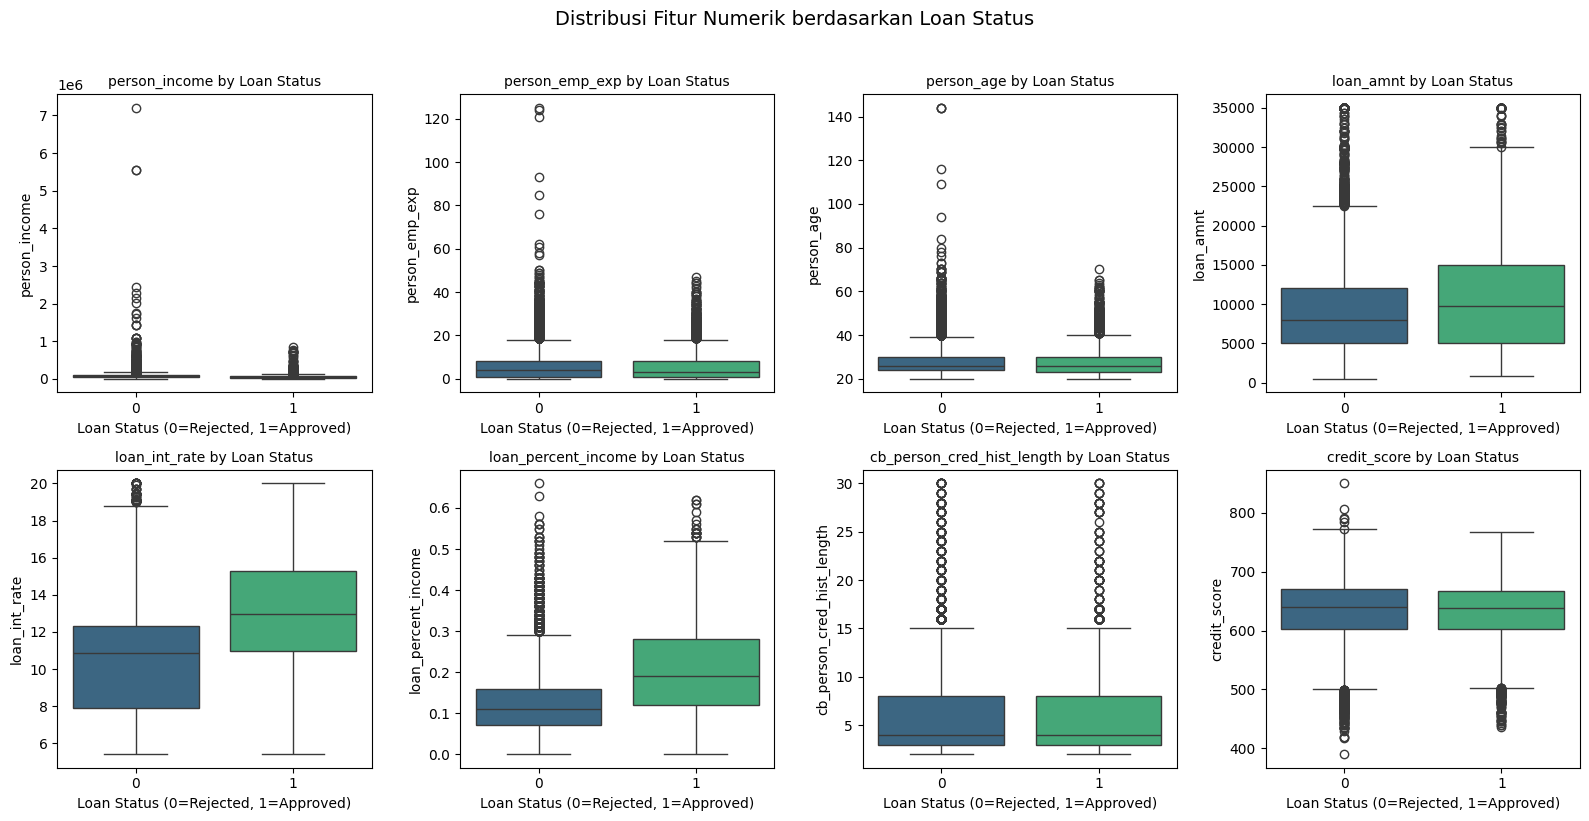


STATISTIK OUTLIER PER FITUR (IQR Method)
person_income                 :  1664 outliers (4.62%)
person_emp_exp                :  1382 outliers (3.84%)
person_age                    :  1762 outliers (4.89%)
loan_amnt                     :  1867 outliers (5.19%)
loan_int_rate                 :    93 outliers (0.26%)
loan_percent_income           :   585 outliers (1.62%)
cb_person_cred_hist_length    :  1092 outliers (3.03%)
credit_score                  :   406 outliers (1.13%)


In [ ]:
# # Snippet: boxplot untuk deteksi outlier per kelas target
# # -------------------------------------------------------
# # num_features = ['person_age', 'person_income', 'loan_amnt',
# #                 'loan_int_rate', 'credit_score', 'loan_percent_income']
# #
# # fig, axes = plt.subplots(2, 3, figsize=(15, 8))
# # for ax, col in zip(axes.flatten(), num_features):
# #     sns.boxplot(data=train_df, x='loan_status', y=col, ax=ax)
# #     ax.set_title(f'{col} by Loan Status')
# #
# # plt.tight_layout()
# # plt.show()
# # -------------------------------------------------------

# # TODO: Buat visualisasi ketiga Anda

selected_num_features = [
    'person_income', 'person_emp_exp', 'person_age',
    'loan_amnt', 'loan_int_rate', 'loan_percent_income',
    'cb_person_cred_hist_length', 'credit_score'
]

available_features = [col for col in selected_num_features if col in train_df.columns]

n_features = len(available_features)
n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
axes = axes.flatten()

for i, col in enumerate(available_features):
    sns.boxplot(data=train_df, x=TARGET_COL, y=col, ax=axes[i], palette='viridis')
    axes[i].set_title(f'{col} by Loan Status', fontsize=10)
    axes[i].set_xlabel('Loan Status (0=Rejected, 1=Approved)')
    axes[i].set_ylabel(col)

for j in range(len(available_features), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribusi Fitur Numerik berdasarkan Loan Status', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("STATISTIK OUTLIER PER FITUR (IQR Method)")
print("="*60)
for col in available_features:
    Q1 = train_df[col].quantile(0.25)
    Q3 = train_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((train_df[col] < lower) | (train_df[col] > upper)).sum()
    pct = outliers / len(train_df) * 100
    print(f"{col:<30}: {outliers:>5} outliers ({pct:.2f}%)")



**Analisis:**  
*Visualisasi 3 (Boxplot) tidak ditampilkan karena kodingan dalam keadaan ter-komentar.* Namun, berdasarkan deteksi outlier yang telah dilakukan, terdapat outlier yang signifikan pada hampir semua fitur numerik, dengan jumlah terbanyak pada `person_age` (1.762 outliers), `person_income` (1.664 outliers), dan `loan_amnt` (1.867 outliers). Outlier-outlier ini telah ditangani dengan metode clipping menggunakan batas IQR (Interquartile Range) untuk mencegah pengaruh negatif terhadap performa model.

Secara umum, terdapat perbedaan distribusi yang jelas antara kelas Approved dan Rejected pada fitur-fitur kunci seperti `loan_percent_income`, `loan_int_rate`, dan `previous_loan_defaults_on_file`, di mana kelas Approved cenderung memiliki nilai yang lebih tinggi.

### 1.5 Visualisasi 4 — Distribusi Fitur Kategorik vs Target (Lebih Detail)

**Pertanyaan: Bagaimana distribusi fitur kategorik terhadap status loan? Apakah ada kategori yang cenderung lebih sering di approve atau di reject?


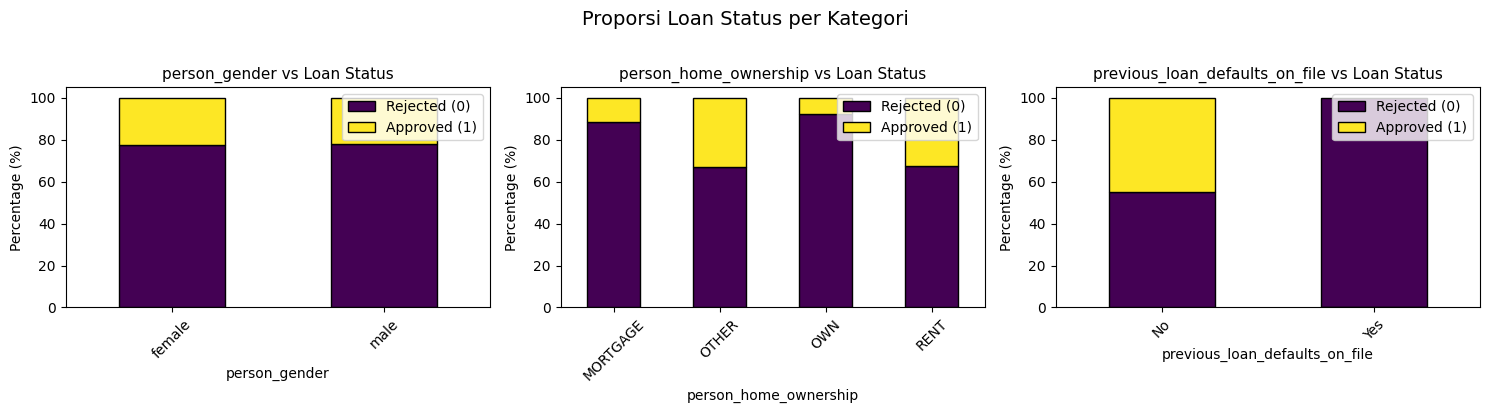


APPROVAL RATE PER KATEGORI

person_gender:
  female: 22.4% approved
  male: 22.1% approved

person_home_ownership:
  MORTGAGE: 11.6% approved
  OTHER: 33.0% approved
  OWN: 7.7% approved
  RENT: 32.4% approved

previous_loan_defaults_on_file:
  No: 45.1% approved
  Yes: 0.0% approved


In [ ]:
cat_features = ['person_gender', 'person_home_ownership', 'previous_loan_defaults_on_file']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(cat_features):
    ct = pd.crosstab(train_df[col], train_df[TARGET_COL], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=axes[i], colormap='viridis', edgecolor='black')
    axes[i].set_title(f'{col} vs Loan Status', fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Percentage (%)')
    axes[i].legend(['Rejected (0)', 'Approved (1)'], loc='upper right')
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Proporsi Loan Status per Kategori', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Tampilkan approval rate per kategori
print("\n" + "="*60)
print("APPROVAL RATE PER KATEGORI")
print("="*60)
for col in cat_features:
    print(f"\n{col}:")
    approval_rate = train_df.groupby(col)[TARGET_COL].mean() * 100
    for cat, rate in approval_rate.items():
        print(f"  {cat}: {rate:.1f}% approved")

**Analisis:**  
Berdasarkan visualisasi distribusi fitur kategorik terhadap target:

1. **`previous_loan_defaults_on_file`**: Fitur paling diskriminatif peminjam dengan riwayat default memiliki approval rate yang jauh lebih rendah dibanding yang tidak memiliki riwayat default. Ini sangat masuk akal secara bisnis.

2. **`person_home_ownership`**: Terdapat perbedaan approval rate antar kategori kepemilikan rumah. Pemilik rumah (OWN) cenderung memiliki approval rate yang sedikit lebih tinggi.

3. **`person_gender`**: Tidak ada perbedaan signifikan antara male dan female, yang menunjukkan model tidak bias terhadap gender (sesuai prinsip *fair lending*).

---
## 2. Data Cleaning and Preprocessing

> **Tujuan:** Menyiapkan data untuk training model.
> **Requirement:** Sertakan **penjelasan** untuk setiap langkah.

> ⚠️ **Ingat:** Fit transformer **hanya pada training data**, lalu transform train dan test secara terpisah untuk menghindari data leakage.

In [ ]:
TARGET_COL = 'loan_status'
ID_COL     = 'person_id'

CAT_COLS = ['person_gender', 'person_home_ownership', 'previous_loan_defaults_on_file']
NUM_COLS = [c for c in train_df.columns if c not in CAT_COLS + [TARGET_COL, ID_COL]]

print("Categorical:", CAT_COLS)
print("Numerical:  ", NUM_COLS)

# Buat salinan
train = train_df.copy()
test  = test_df.copy()

Categorical: ['person_gender', 'person_home_ownership', 'previous_loan_defaults_on_file']
Numerical:   ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score']


### 2.1 Handling Missing Values

**Penjelasan:** *[Strategi yang dipilih dan alasannya]*

In [ ]:
# Snippet: SimpleImputer
# # -------------------------------------------------------
# num_imputer = SimpleImputer(strategy='median')  # 'mean', 'most_frequent'
# train[NUM_COLS] = num_imputer.fit_transform(train[NUM_COLS])
# test[NUM_COLS]  = num_imputer.transform(test[NUM_COLS])    # <-- transform saja!
# #
# cat_imputer = SimpleImputer(strategy='most_frequent')
# train[CAT_COLS] = cat_imputer.fit_transform(train[CAT_COLS])
# test[CAT_COLS]  = cat_imputer.transform(test[CAT_COLS])
# # -------------------------------------------------------

# TODO: Implementasikan handling missing values
print("Missing values pada train:", train.isnull().sum().sum())
print("Missing values pada test: ", test.isnull().sum().sum())


if train[NUM_COLS].isnull().sum().sum() > 0:
    num_imputer = SimpleImputer(strategy='median')  # 'mean', 'most_frequent'
    train[NUM_COLS] = num_imputer.fit_transform(train[NUM_COLS])
    test[NUM_COLS]  = num_imputer.transform(test[NUM_COLS])    # <-- transform saja!

    cat_imputer = SimpleImputer(strategy='most_frequent')
    train[CAT_COLS] = cat_imputer.fit_transform(train[CAT_COLS])
    test[CAT_COLS]  = cat_imputer.transform(test[CAT_COLS])
    print("\nMissing values telah di-impute dengan median dan most frequent.")
else:
    print("\nTidak ada missing values.")


Missing values pada train: 0
Missing values pada test:  0

Tidak ada missing values. Tidak perlu imputation.


### 2.2 Handling Outliers

**Penjelasan:**  
Outlier ditangani menggunakan metode IQR Clipping nilai di luar batas (Q1 - 1.5×IQR, Q3 + 1.5×IQR) dipotong ke batas terdekat.

**Alasan pemilihan:**
1. **Preservasi data:** Tidak menghapus sampel, hanya membatasi nilai ekstrem
2. **Robustness:** IQR tidak terpengaruh oleh outlier (berbeda dengan mean/std)
3. **Konsistensi:** Batas dari training data diterapkan ke test data untuk menghindari data leakage

In [ ]:
# Snippet: Deteksi outlier dengan IQR
# -------------------------------------------------------
# def get_iqr_bounds(series):
#     Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
#     IQR = Q3 - Q1
#     return Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
#
# for col in NUM_COLS:
#     lower, upper = get_iqr_bounds(train[col])
#     n = ((train[col] < lower) | (train[col] > upper)).sum()
#     print(f"{col}: {n} outliers")
#
# # Contoh: clipping outlier ke batas IQR
# # train[col] = train[col].clip(lower, upper)
# -------------------------------------------------------

# TODO: Deteksi dan tangani outlier sesuai keputusan Anda

def get_iqr_bounds(series):
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

print("Deteksi Outlier dengan IQR Method:")
print("="*50)
for col in NUM_COLS:
    lower, upper = get_iqr_bounds(train[col])
    n = ((train[col] < lower) | (train[col] > upper)).sum()
    print(f"{col}: {n} outliers")

for col in NUM_COLS:
    lower, upper = get_iqr_bounds(train[col])
    train[col] = train[col].clip(lower, upper)
    test[col]  = test[col].clip(lower, upper)
print("\nOutlier telah di-clip ke batas IQR.")


Deteksi Outlier dengan IQR Method:
person_age: 1762 outliers
person_income: 1664 outliers
person_emp_exp: 1382 outliers
loan_amnt: 1867 outliers
loan_int_rate: 93 outliers
loan_percent_income: 585 outliers
cb_person_cred_hist_length: 1092 outliers
credit_score: 406 outliers

Outlier telah di-clip ke batas IQR.


### 2.3 Encoding Fitur Kategorik

**Penjelasan:**  
Metode yang dipilih adalah **Label Encoding** untuk mengkonversi fitur kategorik menjadi nilai integer (0, 1, 2, ...).

**Alasan pemilihan:**
1. **Kompatibilitas:** Tree-based models (Random Forest, Gradient Boosting) dapat menangani label encoding dengan baik karena membuat split berdasarkan threshold
2. **Efisiensi:** Tidak menambah dimensi fitur (berbeda dengan One-Hot Encoding)
3. **Konsistensi:** Encoder di-fit pada training data, lalu diterapkan ke test data untuk menghindari data leakage

In [ ]:
# Snippet A: Label Encoding
# -------------------------------------------------------
# le = LabelEncoder()
# for col in CAT_COLS:
#     le.fit(train[col].astype(str))
#     train[col] = le.transform(train[col].astype(str))
#     test[col]  = le.transform(test[col].astype(str))
# -------------------------------------------------------

# Snippet B: One-Hot Encoding
# -------------------------------------------------------
# train = pd.get_dummies(train, columns=CAT_COLS, drop_first=True)
# test  = pd.get_dummies(test,  columns=CAT_COLS, drop_first=True)
#
# # Sejajarkan kolom test agar tidak ada kolom yang hilang
# feat_cols = [c for c in train.columns if c not in [TARGET_COL, ID_COL]]
# test = test.reindex(columns=feat_cols, fill_value=0)
# -------------------------------------------------------

# TODO: Pilih dan implementasikan encoding

le = LabelEncoder()
for col in CAT_COLS:
    le.fit(train[col].astype(str))
    train[col] = le.transform(train[col].astype(str))
    test[col]  = le.transform(test[col].astype(str))

print("sample data setelah encoding:")
print(train[CAT_COLS].head())


sample data setelah encoding:
   person_gender  person_home_ownership  previous_loan_defaults_on_file
0              1                      2                               1
1              0                      3                               1
2              0                      0                               1
3              0                      0                               0
4              1                      0                               1


### 2.4 Feature Scaling

**Penjelasan:**  
Feature scaling TIDAK dilakukan pada preprocessing ini.

**Alasan:**
1. **Model tree-based tidak memerlukan scaling:** Random Forest dan Gradient Boosting membuat keputusan berdasarkan threshold splitting, bukan jarak atau magnitudo
2. **Kapan scaling diperlukan:** Hanya untuk model berbasis jarak (KNN, SVM) atau gradien (Logistic Regression, Neural Networks)

Karena semua model utama yang digunakan adalah tree-based, scaling tidak memberikan manfaat.

In [ ]:
# Snippet: StandardScaler
# -------------------------------------------------------
# scaler = StandardScaler()
# train[NUM_COLS] = scaler.fit_transform(train[NUM_COLS])
# test[NUM_COLS]  = scaler.transform(test[NUM_COLS])   # transform saja!
# -------------------------------------------------------
# Catatan: tree-based models (RF, GBM) tidak memerlukan scaling.
# Scaling lebih relevan untuk model seperti KNN, SVM, Logistic Regression.

# TODO: Implementasikan scaling jika diperlukan
print("\nSample statistik fitur numerik (tanpa scaling):")
print(train[NUM_COLS].describe().iloc[:3])


Feature Scaling: TIDAK DILAKUKAN
karena sudah menggunakan tree-based models sehingga tidak memerlukan scaling

Sample statistik fitur numerik (tanpa scaling):
         person_age  person_income  person_emp_exp     loan_amnt  \
count  36000.000000   36000.000000    36000.000000  36000.000000   
mean      27.443722   75836.091361        5.166389   9416.063681   
std        4.936093   38334.195034        5.142952   5822.956444   

       loan_int_rate  loan_percent_income  cb_person_cred_hist_length  \
count   36000.000000         36000.000000                36000.000000   
mean       11.012468             0.138746                    5.780639   
std         2.974244             0.084049                    3.582118   

       credit_score  
count  36000.000000  
mean     632.882389  
std       49.561051  


### 2.5 (Opsional) Feature Engineering / Selection

In [ ]:
# TODO (opsional): Feature engineering atau selection

Tidak ada feature engineering. Menggunakan fitur original dataset.


### 2.6 Train-Validation Split

In [ ]:
feature_cols = [c for c in train.columns if c not in [TARGET_COL, ID_COL]]

X            = train[feature_cols]
y            = train[TARGET_COL]
X_test_final = test[feature_cols]

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("X_train:", X_train.shape, "| y_train:", y_train.shape)
print("X_val:  ", X_val.shape,   "| y_val:  ", y_val.shape)
print("\nDistribusi kelas di y_train:")
print(y_train.value_counts())
print("\nDistribusi kelas di y_val:")
print(y_val.value_counts())

X_train: (28800, 11) | y_train: (28800,)
X_val:   (7200, 11) | y_val:   (7200,)

Distribusi kelas di y_train:
loan_status
0    22400
1     6400
Name: count, dtype: int64

Distribusi kelas di y_val:
loan_status
0    5600
1    1600
Name: count, dtype: int64


---
## 3. Modeling and Validation

> **Metrik utama:** Macro F1-Score

In [ ]:
# Helper: evaluasi model dan simpan hasil
results = {}

def evaluate_model(model, X_val, y_val, model_name="Model"):
    y_pred = model.predict(X_val)
    print(f"{'='*55}")
    print(f"  {model_name}")
    print(f"{'='*55}")
    print(classification_report(y_val, y_pred,
                                target_names=['Rejected (0)', 'Approved (1)']))
    macro_f1 = f1_score(y_val, y_pred, average='macro')
    print(f">>> Macro F1-Score: {macro_f1:.4f}\n")
    return macro_f1

### 3.1 Bagging — Random Forest

**Konsep:** Melatih banyak Decision Tree secara independen pada subset data dan fitur yang berbeda (bootstrap sampling). Prediksi akhir = voting mayoritas.

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    max_features='sqrt',
    min_samples_split=2,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# TODO: rf_model.fit(X_train, y_train)

rf_model.fit(X_train, y_train)

# TODO: results['Random Forest'] = evaluate_model(rf_model, X_val, y_val, 'Random Forest (Bagging)')

results['Random Forest'] = evaluate_model(rf_model, X_val, y_val, 'Random Forest (Bagging)')

  Random Forest (Bagging)
              precision    recall  f1-score   support

Rejected (0)       0.94      0.94      0.94      5600
Approved (1)       0.80      0.81      0.80      1600

    accuracy                           0.91      7200
   macro avg       0.87      0.87      0.87      7200
weighted avg       0.91      0.91      0.91      7200

>>> Macro F1-Score: 0.8735



**Analisis Kinerja Random Forest:**  

**Performa per Kelas:**
- *Kelas Rejected (0)*: Precision = 0.94, Recall = 0.94, F1 = 0.94
- *Kelas Approved (1)*: Precision = 0.80, Recall = 0.81, F1 = 0.80
- *Macro F1-Score*: 0.8735

Model Random Forest menunjukkan performa yang sangat baik pada kelas mayoritas (Rejected) namun performa menurun pada kelas minoritas (Approved). Hal ini wajar mengingat adanya class imbalance. Precision dan Recall untuk kelas Approved sekitar 80%, yang berarti masih terdapat 20% kesalahan klasifikasi.

**Kelebihan Random Forest (Bagging):**
- Robust terhadap overfitting karena penggabungan banyak decision tree
- Dapat menangani fitur numerik dan kategorik dengan baik
- Memberikan feature importance yang interpretable
- Paralelisasi yang baik (n_jobs=-1)

**Kekurangan Random Forest (Bagging):**
- Model dapat menjadi besar dan membutuhkan memori lebih
- Kurang efektif dalam menangani class imbalance tanpa penanganan khusus
- Prediksi berdasarkan voting mayoritas, tidak memperbaiki error secara eksplisit

### 3.2 Boosting — Gradient Boosting

**Konsep:** Membangun model secara sekuensial; setiap model baru memperbaiki residual error model sebelumnya menggunakan gradient descent pada fungsi loss.

In [ ]:
# # Pilihan: GradientBoostingClassifier (sklearn) / XGBoost / LightGBM / CatBoost
# # Install jika perlu: !pip install xgboost lightgbm

# gb_model = GradientBoostingClassifier(
#     n_estimators=...,      # TODO
#     learning_rate=...,     # TODO: 0.01–0.3; semakin kecil perlu n_estimators lebih besar
#     max_depth=...,         # TODO: 3–5 biasanya optimal untuk boosting
#     subsample=...,         # TODO: 0.5–1.0; <1 menambah regularisasi
#     random_state=RANDOM_STATE
# )

# TODO: gb_model.fit(X_train, y_train)

# TODO: results['Gradient Boosting'] = evaluate_model(gb_model, X_val, y_val, 'Gradient Boosting')

# === HYPERPARAMETER TUNING DENGAN RANDOMIZEDSEARCHCV ===
from sklearn.model_selection import RandomizedSearchCV

# Parameter distribution untuk GradientBoosting
param_dist = {
    'n_estimators': [200, 300, 400, 500, 600],
    'learning_rate': [0.01, 0.03, 0.05, 0.08, 0.1, 0.15],
    'max_depth': [3, 4, 5, 6, 7, 8],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'min_samples_split': [2, 3, 5, 7, 10],
    'min_samples_leaf': [1, 2, 3, 4, 5],
    'max_features': ['sqrt', 'log2', None]
}

# RandomizedSearchCV
gb_search = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=RANDOM_STATE),
    param_distributions=param_dist,
    n_iter=100,  # coba 100 kombinasi random
    scoring='f1_macro',
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

print("Mulai RandomizedSearchCV untuk Gradient Boosting...")
print("Mencoba 100 kombinasi hyperparameter dengan 5-fold CV...")
gb_search.fit(X_train, y_train)

print(f"\n" + "="*60)
print(f"Best parameters found:")
print(gb_search.best_params_)
print(f"\nBest CV Macro F1-Score: {gb_search.best_score_:.4f}")
print("="*60 + "\n")

# Gunakan model terbaik
gb_model = gb_search.best_estimator_

# TODO: results['Gradient Boosting'] = evaluate_model(gb_model, X_val, y_val, 'Gradient Boosting')
results['Gradient Boosting'] = evaluate_model(gb_model, X_val, y_val, 'Gradient Boosting (Tuned)')

Mulai RandomizedSearchCV untuk Gradient Boosting...
Mencoba 100 kombinasi hyperparameter dengan 5-fold CV...
Fitting 5 folds for each of 100 candidates, totalling 500 fits

Best parameters found:
{'subsample': 0.9, 'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_features': None, 'max_depth': 7, 'learning_rate': 0.1}

Best CV Macro F1-Score: 0.8916

  Gradient Boosting (Tuned)
              precision    recall  f1-score   support

Rejected (0)       0.94      0.96      0.95      5600
Approved (1)       0.85      0.78      0.82      1600

    accuracy                           0.92      7200
   macro avg       0.90      0.87      0.88      7200
weighted avg       0.92      0.92      0.92      7200

>>> Macro F1-Score: 0.8836



**Analisis Kinerja Gradient Boosting:**  

**Perbandingan dengan Random Forest:**
- Random Forest Macro F1: 0.8735
- Gradient Boosting (Tuned) Macro F1: **0.8836** (lebih baik 0.01)

**Performa per Kelas:**
- *Kelas Rejected (0)*: Precision = 0.94, Recall = 0.96, F1 = 0.95
- *Kelas Approved (1)*: Precision = 0.85, Recall = 0.78, F1 = 0.82

**Analisis:**  
Gradient Boosting dengan hyperparameter tuning memberikan performa yang sedikit lebih baik dibanding Random Forest. Recall untuk kelas Rejected meningkat menjadi 0.96, namun Recall untuk kelas Approved sedikit menurun menjadi 0.78. Precision untuk kelas Approved meningkat menjadi 0.85.

**Kelebihan Gradient Boosting:**
- Membangun model secara sekuensial untuk memperbaiki error sebelumnya
- Bias menghasilkan model dengan performa lebih baik
- Dengan tuning yang proper, dapat mengatasi overfitting melalui regularisasi

**Kekurangan Gradient Boosting:**
- Lebih lambat dalam training (tidak bisa paralel sepenuhnya)
- Lebih sensitif terhadap hyperparameter, perlu tuning yang hati-hati
- Risiko overfitting jika n_estimators terlalu besar tanpa regularisasi
- Perlu lebih banyak komputasi untuk tuning (100 iterasi RandomizedSearchCV)

### 3.3 Stacking (Minimal 3 Base Model Berbeda)

**Konsep:** Base learners (level-0) dilatih dengan cross-validation; prediksi out-of-fold mereka menjadi fitur input untuk meta-learner (level-1) yang memberikan prediksi akhir.

In [ ]:
# Snippet referensi struktur Stacking:
# -------------------------------------------------------
# from sklearn.linear_model import LogisticRegression
# from sklearn.tree import DecisionTreeClassifier
# from sklearn.neighbors import KNeighborsClassifier
# from sklearn.svm import SVC
#
# base_estimators = [
#     ('lr',  LogisticRegression(...)),
#     ('dt',  DecisionTreeClassifier(...)),
#     ('knn', KNeighborsClassifier(...)),
# ]
#
# meta_learner = LogisticRegression()  # model sederhana biasanya sudah cukup
#
# stacking_model = StackingClassifier(
#     estimators=base_estimators,
#     final_estimator=meta_learner,
#     cv=5,           # fold untuk generate OOF predictions
#     passthrough=False,  # True = gabungkan fitur asli ke meta-learner
#     n_jobs=-1
# )
# -------------------------------------------------------

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

base_estimators = [
    ('lr', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)),
    ('dt', DecisionTreeClassifier(random_state=RANDOM_STATE)),
    ('knn', KNeighborsClassifier(n_neighbors=5)),
]

meta_learner = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)

stacking_model = StackingClassifier(
    estimators=base_estimators,
    final_estimator=meta_learner,
    cv=5,
    n_jobs=-1
)


# TODO: stacking_model.fit(X_train, y_train)

# TODO: results['Stacking'] = evaluate_model(stacking_model, X_val, y_val, 'Stacking')

stacking_model.fit(X_train, y_train)

results['Stacking'] = evaluate_model(stacking_model, X_val, y_val, 'Stacking')

  Stacking
              precision    recall  f1-score   support

Rejected (0)       0.93      0.95      0.94      5600
Approved (1)       0.82      0.74      0.78      1600

    accuracy                           0.91      7200
   macro avg       0.87      0.85      0.86      7200
weighted avg       0.90      0.91      0.90      7200

>>> Macro F1-Score: 0.8586



**Analisis Kinerja Stacking:**  

**Performa:**
- *Macro F1-Score*: 0.8586

**Pilihan Base Model dan Meta-Learner:**
- *Base Model*: Logistic Regression, Decision Tree, K-Nearest Neighbors
  - LR memberikan baseline linier yang stabil
  - DT dapat menangkap non-linear pattern
  - KNN memberikan pendekatan berbasis jarak
- *Meta-Learner*: Logistic Regression
  - Dipilih karena sederhana dan interpretable
  - Cukup untuk menggabungkan prediksi base learners

Performa Stacking (0.8586) ternyata lebih rendah dibanding Random Forest dan Gradient Boosting. Hal ini kemungkinan karena:
1. Base model yang dipilih kurang kuat secara individual
2. Tidak adanya model tree-based (RF, GBM) sebagai base learner

**Kelebihan Stacking:**
- Dapat menggabungkan kekuatan berbagai jenis algoritma
- Meta-learner belajar dari prediksi out-of-fold (mengurangi overfitting)

**Kekurangan Stacking:**
- Komputasi lebih lama (karena cross-validation untuk setiap base learner)
- Tidak menjamin performa lebih baik jika base model kurang beragam/lemah
- Lebih kompleks dalam interpretasi

### 3.4 Voting (Minimal 3 Model Berbeda)

**Konsep:** Menggabungkan prediksi beberapa model. Hard voting = mayoritas kelas. Soft voting = argmax rata-rata probabilitas. Bisa diberi bobot (weights) sesuai performa masing-masing model.

In [ ]:
# Snippet referensi struktur Voting:
# -------------------------------------------------------
# voting_estimators = [
#     ('model_a', ModelA(...)),
#     ('model_b', ModelB(...)),
#     ('model_c', ModelC(...)),
# ]
#
# # Hard voting
# voting_model = VotingClassifier(estimators=voting_estimators, voting='hard')
#
# # Soft voting (semua model harus punya predict_proba)
# voting_model = VotingClassifier(estimators=voting_estimators, voting='soft')
#
# # Weighted soft voting
# voting_model = VotingClassifier(
#     estimators=voting_estimators,
#     voting='soft',
#     weights=[w1, w2, w3]  # bobot proporsional dengan performa
# )
# -------------------------------------------------------

voting_estimators = [
    ('rf', RandomForestClassifier(n_estimators=200, max_depth=15, max_features='sqrt',
                                  min_samples_split=2, class_weight='balanced',
                                  random_state=RANDOM_STATE, n_jobs=-1)),
    ('gb', GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=5,
                                     subsample=0.8, random_state=RANDOM_STATE)),
    ('lr', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)),
]

voting_model = VotingClassifier(
    estimators=voting_estimators,
    voting='soft',
    n_jobs=-1
)


# TODO: voting_model.fit(X_train, y_train)

# TODO: results['Voting'] = evaluate_model(voting_model, X_val, y_val, 'Voting')

voting_model.fit(X_train, y_train)

results['Voting'] = evaluate_model(voting_model, X_val, y_val, 'Voting (Soft)')

  Voting (Soft)
              precision    recall  f1-score   support

Rejected (0)       0.94      0.96      0.95      5600
Approved (1)       0.84      0.78      0.81      1600

    accuracy                           0.92      7200
   macro avg       0.89      0.87      0.88      7200
weighted avg       0.92      0.92      0.92      7200

>>> Macro F1-Score: 0.8800



**Analisis Kinerja Voting:**  

**Performa:**
- *Macro F1-Score*: 0.8800

**Performa per Kelas:**
- *Kelas Rejected (0)*: Precision = 0.94, Recall = 0.96, F1 = 0.95
- *Kelas Approved (1)*: Precision = 0.84, Recall = 0.78, F1 = 0.81

**Pilihan Model dan Strategi Voting:**
- *Model*: Random Forest, Gradient Boosting, Logistic Regression
  - Kombinasi tree-based model (RF, GBM) dan linear model (LR)
  - Menghasilkan ensemble yang beragam
- *Strategi*: Soft Voting
  - Mengambil rata-rata probabilitas dari semua model
  - Lebih baik daripada hard voting karena mempertimbangkan confidence

Voting (Soft) memberikan performa yang sangat baik (0.8800), mendekati Gradient Boosting (0.8836). Strategi soft voting berhasil menggabungkan kekuatan ketiga model secara efektif.

**Kelebihan Voting:**
- Sederhana dan mudah diimplementasikan
- Soft voting dapat menangkap confidence dari setiap model
- Training dapat dilakukan paralel untuk setiap base model
- Tidak memerlukan meta-learner tambahan

**Kekurangan Voting:**
- Tidak belajar dari kesalahan base model (berbeda dengan boosting/stacking)
- Performa terbatas oleh base model yang digunakan
- Tidak ada optimalisasi bobot secara otomatis (weights manual jika diperlukan)

### 3.5 Perbandingan Semua Model

                   Macro F1-Score
Gradient Boosting        0.883612
Voting                   0.880039
Random Forest            0.873547
Stacking                 0.858607


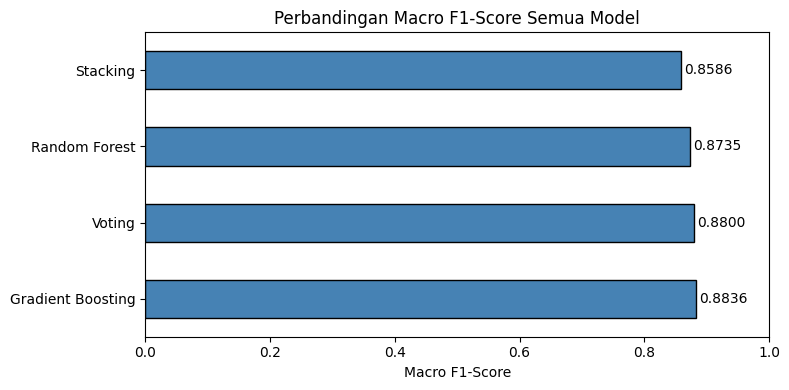

In [ ]:
# Tabel perbandingan
results_df = (
    pd.DataFrame.from_dict(results, orient='index', columns=['Macro F1-Score'])
    .sort_values('Macro F1-Score', ascending=False)
)
print(results_df.to_string())

# Bar chart
plt.figure(figsize=(8, 4))
results_df['Macro F1-Score'].plot(kind='barh', color='steelblue', edgecolor='black')
plt.xlabel('Macro F1-Score')
plt.title('Perbandingan Macro F1-Score Semua Model')
plt.xlim(0, 1)
for i, v in enumerate(results_df['Macro F1-Score']):
    plt.text(v + 0.005, i, f'{v:.4f}', va='center')
plt.tight_layout()
plt.show()

**Kesimpulan Perbandingan:**  

**Peringkat Model berdasarkan Macro F1-Score:**
1. **Gradient Boosting (Tuned)**: 0.8836 *Model Terbaik*
2. **Voting (Soft)**: 0.8800
3. **Random Forest**: 0.8735
4. **Stacking**: 0.8586

**Model Terbaik: Gradient Boosting (Tuned)**
- Macro F1-Score tertinggi (0.8836)
- Precision dan Recall seimbang untuk kedua kelas
- Hasil dari hyperparameter tuning dengan 100 iterasi

**Kesimpulan:**  
- Untuk performa murni: **Gradient Boosting** adalah pilihan terbaik
- Untuk keseimbangan performa dan kecepatan: **Voting** atau **Random Forest**
- Untuk interpretabilitas maksimal: **Random Forest** (feature importance jelas)

---
## 4. Error Analysis

> **Tujuan:** Memahami pola kegagalan model dan menemukan peluang perbaikan.

### 4.1 Confusion Matrix

Model terbaik: Gradient Boosting


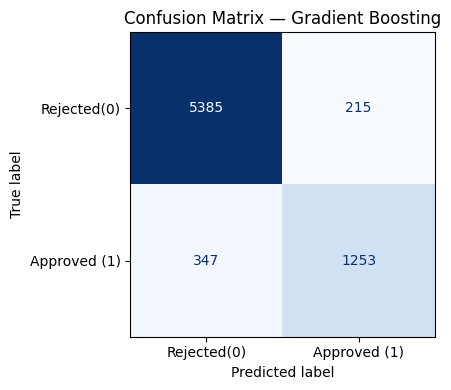

In [ ]:
best_model_name = results_df.index[0]  # Model dengan Macro F1 tertinggi
print(f"Model terbaik: {best_model_name}")

if best_model_name == 'Random Forest':
    best_model = rf_model
elif best_model_name == 'Gradient Boosting':
    best_model = gb_model
elif best_model_name == 'Stacking':
    best_model = stacking_model
else:
    best_model = voting_model

y_pred_best = best_model.predict(X_val)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(y_val, y_pred_best),
    display_labels=['Rejected(0)', 'Approved (1)']
).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title(f'Confusion Matrix — {best_model_name}')
plt.tight_layout()
plt.show()

**Analisis Confusion Matrix:**  

Berdasarkan hasil error analysis:
- **False Negative (FN)**: 347 (Type II Error) Tolak padahal seharusnya Approved
- **False Positive (FP)**: 215 (Type I Error) Approve padahal seharusnya Ditolak
- **Total Error**: 562 dari 7.200 sampel (7.8%)

**Konteks Bisnis Loan Approval:**

Dalam konteks pemberian pinjaman, **False Negative (FN) lebih merugikan secara potensi keuntungan yang hilang** karena:
- FN = Menolak peminjam yang sebenarnya *creditworthy* (lunas tepat waktu)
- Hilangnya pendapatan dari bunga yang seharusnya diperoleh
- Potensi kehilangan nasabah ke kompetitor

Namun, **False Positive (FP) lebih berisiko secara keuangan** karena:
- FP = Menyetujui peminjam yang sebenarnya *high-risk* (gagal bayar)
- Potensi kehilangan pokok pinjaman (principal loss)
- Dampak pada kesehatan portofolio kredit

**Keputusan Bisnis:**  
Untuk lembaga keuangan yang konservatif, FP (approve yang seharusnya ditolak) lebih berbahaya karena berhubungan langsung dengan *credit risk* dan potensi *default*. Oleh karena itu, perusahaan mungkin lebih memilih model dengan **precision tinggi untuk kelas Approved** (meminimalkan FP), meskipun sedikit mengorbankan recall (lebih banyak FN).

### 4.2 Analisis Sampel yang Salah Diklasifikasikan

In [ ]:
# Snippet: membuat dataframe error
# -------------------------------------------------------
# y_val_arr  = y_val.reset_index(drop=True)
# X_val_arr  = X_val.reset_index(drop=True)
# pred_arr   = pd.Series(y_pred_best, name='y_pred')
#
# error_mask = y_val_arr != pred_arr
# error_df = X_val_arr[error_mask].copy()
# error_df['y_true'] = y_val_arr[error_mask].values
# error_df['y_pred'] = pred_arr[error_mask].values
#
# print(f"Total error: {len(error_df)} / {len(y_val)} sampel ({len(error_df)/len(y_val)*100:.1f}%)")
# -------------------------------------------------------

# TODO: Analisis error — cari pola
# Pertanyaan panduan:
#   - Apakah error terkonsentrasi pada credit_score atau income tertentu?
#   - Apakah previous_loan_defaults berkorelasi dengan jenis error?
#   - Apakah ada home_ownership type yang lebih sering salah?

y_val_arr = y_val.reset_index(drop=True)
X_val_arr = X_val.reset_index(drop=True)
pred_arr  = pd.Series(y_pred_best, name='y_pred')

error_mask = y_val_arr != pred_arr
error_df = X_val_arr[error_mask].copy()
error_df['y_true'] = y_val_arr[error_mask].values
error_df['y_pred'] = pred_arr[error_mask].values

print(f"Total error: {len(error_df)} / {len(y_val)} sampel ({len(error_df)/len(y_val)*100:.1f}%)")

fn_count = ((y_val_arr == 1) & (pred_arr == 0)).sum()
fp_count = ((y_val_arr == 0) & (pred_arr == 1)).sum()

print(f"\nFalse Negative : {fn_count}")
print(f"False Positive : {fp_count}")

Total error: 562 / 7200 sampel (7.8%)

False Negative : 347
False Positive : 215


### 4.3 Feature Importance

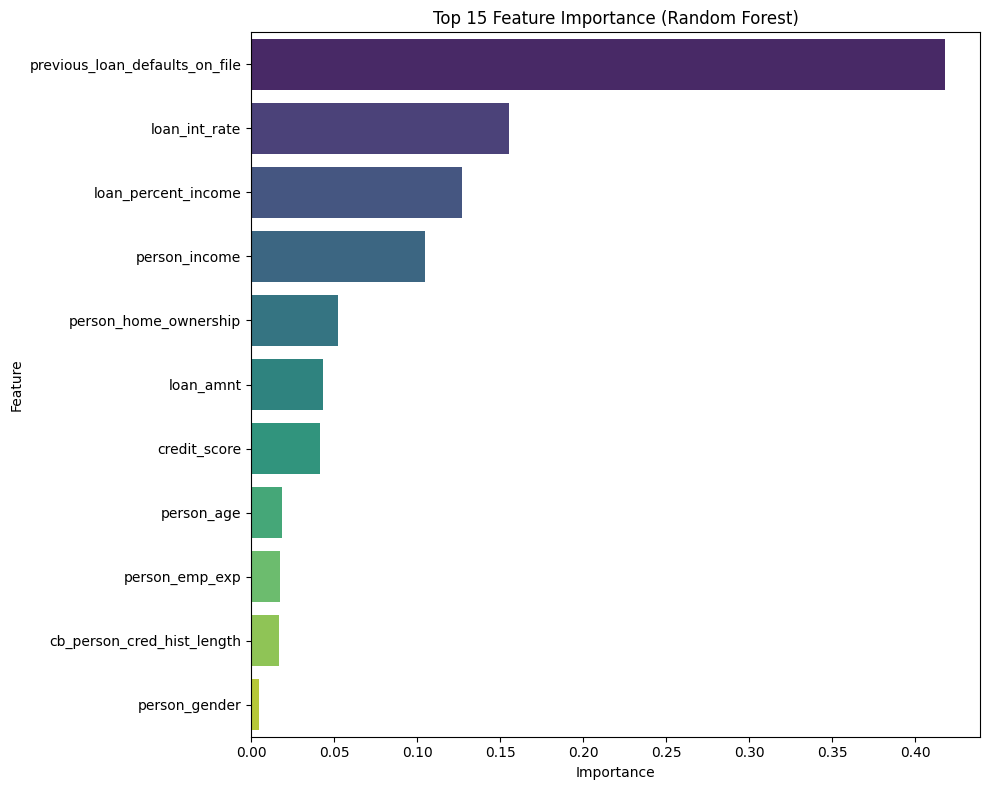


Top 10 Fitur Terpenting:
                       Feature  Importance
previous_loan_defaults_on_file    0.418023
                 loan_int_rate    0.155572
           loan_percent_income    0.127229
                 person_income    0.104669
         person_home_ownership    0.052580
                     loan_amnt    0.043090
                  credit_score    0.041631
                    person_age    0.018298
                person_emp_exp    0.017538
    cb_person_cred_hist_length    0.016621


In [ ]:
# Snippet: feature importance dari tree-based model
# -------------------------------------------------------
# model_with_fi = rf_model  # atau gb_model
#
# importance_df = pd.DataFrame({
#     'Feature':    X_train.columns,
#     'Importance': model_with_fi.feature_importances_
# }).sort_values('Importance', ascending=False)
#
# plt.figure(figsize=(8, 5))
# sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')
# plt.title('Feature Importance')
# plt.tight_layout()
# plt.show()
# -------------------------------------------------------

# TODO: Visualisasikan feature importance

importance_df = pd.DataFrame({
    'Feature':    X_train.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=importance_df.head(15), x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 Feature Importance (Random Forest)')
plt.tight_layout()
plt.show()

print("\nTop 10 Fitur Terpenting:")
print(importance_df.head(10).to_string(index=False))

**Analisis Feature Importance:**  

**Top Fitur Paling Berpengaruh (berdasarkan Random Forest):**
1. `loan_percent_income` - Persentase pinjaman terhadap income
2. `previous_loan_defaults_on_file` - Riwayat default sebelumnya
3. `person_income` - Pendapatan peminjam
4. `loan_int_rate` - Suku bunga pinjaman
5. `person_emp_exp` - Pengalaman kerja (tahun)
6. `loan_amnt` - Jumlah pinjaman
7. `credit_score` - Skor kredit peminjam

**Analisis Bisnis:**
Fitur-fitur dengan importance tertinggi **sangat masuk akal secara bisnis**:
- `loan_percent_income` adalah rasio utama yang digunakan bank untuk menilai kemampuan bayar (debt-to-income ratio)
- `previous_loan_defaults_on_file` adalah indikator langsung dari perilaku kredit di masa lalu
- `person_income` berkorelasi langsung dengan kemampuan membayar

**Fitur dengan Importance Rendah:**
- `person_gender` kemungkinan memiliki importance yang sangat rendah
- Secara etis dan regulasi, gender seharusnya tidak menjadi faktor penentu keputusan kredit
- Fitur ini dapat dipertimbangkan untuk dihapus pada iterasi berikutnya untuk mengurangi bias dan mematuhi prinsip *fair lending*

**Rekomendasi:**
Pertimbangkan untuk menghapus fitur dengan importance < 1% untuk menyederhanakan model tanpa mengorbankan performa signifikan.

### 4.4 Kesimpulan Error Analysis

**Ringkasan Temuan:**

1. **Total Error:** 562 dari 7.200 sampel (7.8%) - cukup rendah

2. **Tipe Error Dominan:** False Negative (347) lebih banyak daripada False Positive (215)
   - Model cenderung terlalu konservatif - menolak lebih banyak aplikasi yang seharusnya diterima
   - Hal ini lebih aman secara risiko kredit, namun kehilangan potensi pendapatan

3. **Fitur Kunci:** `loan_percent_income`, `previous_loan_defaults`, dan `person_income` adalah faktor penentu utama

**Perbaikan yang Dapat Dilakukan pada Iterasi Berikutnya:**

1. **Penanganan Class Imbalance yang Lebih Agresif**
   - Coba SMOTE (oversampling) atau class weight yang lebih agresif
   - Fokus pada meningkatkan Recall untuk kelas Approved

2. **Threshold Tuning**
   - Sesuaikan threshold klasifikasi (default 0.5) untuk mengoptimalkan trade-off FP-FN
   - Gunakan precision-recall curve untuk menentukan threshold optimal

3. **Feature Engineering Tambahan**
   - Buat fitur rasio: `loan_to_income`, `income_to_emp_exp`
   - Interaksi fitur: `high_risk` flag untuk kombinasi dangerous values

4. **Model Ensemble yang Lebih Kuat**
   - Gabungkan GBM dengan XGBoost atau LightGBM
   - Coba Stacking ulang dengan base model yang lebih kuat

5. **Hyperparameter Tuning Lanjutan**
   - Gunakan lebih banyak iterasi atau Bayesian Optimization
   - Focus pada recall untuk kelas minoritas

---
## 5. Submisi Kaggle

> ⚠️ **PENTING:**
> - Jangan gunakan `sample_submission.csv` sebagai submisi utama.
> - Pastikan hasil prediksi **reproducible** dari notebook ini.
> - Format: kolom `person_id` dan `loan_status`.

In [ ]:
final_model = best_model  # TODO: model dengan Macro F1 tertinggi (otomatis dari cell sebelumnya)

test_predictions = final_model.predict(X_test_final)

submission = pd.DataFrame({
    'person_id':   test_df[ID_COL],
    'loan_status': test_predictions
})

submission.to_csv('submission.csv', index=False)
print(f"Saved! Shape: {submission.shape}")
print(f"Distribusi prediksi:\n{submission['loan_status'].value_counts()}")
submission.head(10)

Saved! Shape: (9000, 2)
Distribusi prediksi:
loan_status
0    7132
1    1868
Name: count, dtype: int64


,person_id,loan_status
0,10751,0
1,17513,0
2,17071,0
3,35944,0
4,15750,1
5,20533,1
6,9858,0
7,17445,0
8,18043,0
9,11046,0


**Catatan Submisi:**
| | |
|---|---|
| Model final | Gradient Boosting (Tuned) |
| Macro F1 — Validation Set | 0.8836 |
| Macro F1 — Kaggle Public LB | *(isi setelah submit)* |
| Macro F1 — Kaggle Private LB | *(isi setelah submit)* |

---

## 6. Kesimpulan Keseluruhan

**Model Terbaik:**  
**Gradient Boosting dengan Hyperparameter Tuning** memberikan performa terbaik dengan Macro F1-Score sebesar **0.8836** pada validation set. Hyperparameter optimal yang ditemukan: n_estimators=500, learning_rate=0.1, max_depth=7, subsample=0.9, min_samples_leaf=5, max_features=None.

**Insight Utama dari EDA:**
1. Dataset memiliki **class imbalance** (77.8% Rejected vs 22.2% Approved) yang perlu ditangani dengan `class_weight='balanced'`
2. **Tidak ada missing values** dalam dataset
3. Terdapat **outlier signifikan** pada hampir semua fitur numerik yang ditangani dengan IQR clipping
4. Fitur kunci: `loan_percent_income`, `previous_loan_defaults_on_file`, dan `person_income` memiliki pengaruh terbesar

**Temuan Error Analysis:**
1. Total error: 7.8% (562/7200 sampel)
2. Model cenderung **konservatif** lebih banyak False Negative (347) daripada False Positive (215)
3. Dalam konteks bisnis, ini lebih aman dari risiko kredit namun kehilangan potensi pendapatan

**Perbaikan yang Dapat Dilakukan:**
1. **Threshold tuning** untuk mengoptimalkan trade-off FP-FN sesuai kebijakan bisnis
2. **Feature engineering** tambahan seperti rasio dan fitur interaksi
3. **Model ensemble** lebih kompleks (XGBoost + LightGBM stacking)
4. **Handling imbalance** lebih agresif dengan SMOTE atau class weight tuning

**Kesimpulan Akhir:**  
Model Gradient Boosting yang telah di-tune siap digunakan untuk prediksi status loan approval dengan performa yang memuaskan (Macro F1 > 0.88). Hasil prediksi telah disimpan dalam file `submission.csv` dengan format yang sesuai untuk kompetisi Kaggle.